In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_excel("/content/master_final.xlsx")

In [3]:
#customer clustering
customer_clustering = df.groupby("customer_unique_id").agg(last_purchase_date = ("order_purchase_timestamp", "max"), frequency = ("order_id", "nunique"), monetary = ("price", "sum"))

In [5]:
snapshot_date = df["order_purchase_timestamp"].max()

In [8]:
customer_clustering["recency"] = (snapshot_date - customer_clustering["last_purchase_date"]).dt.days

In [13]:
clustering_feature = customer_clustering[["frequency", "monetary", "recency"]].copy()

In [16]:
scaler = StandardScaler()

scaled_feature = scaler.fit_transform(clustering_feature)

In [22]:
#to figure out how many clusters we want , Elbow method, silhoutte score

from sklearn.cluster import KMeans

inertia = []

k_range = range(2,10) # Changed from (2,9) to range(2,10) to get values from 2 to 9

for k in k_range:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  kmeans.fit(scaled_feature)
  inertia.append(kmeans.inertia_)

print("K values", list(k_range))
print("Inertia", inertia)

K values [2, 3, 4, 5, 6, 7, 8, 9]
Inertia [206640.0864296494, 141377.5509342622, 94309.96399718372, 79307.5212269012, 64784.1258661204, 55227.25372001272, 49192.17567670137, 45011.62430235157]


<function matplotlib.pyplot.show(close=None, block=None)>

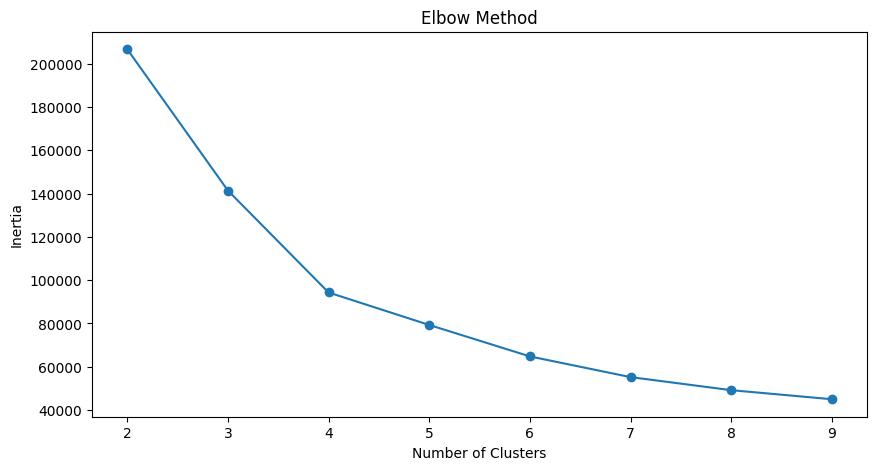

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10, 5))

plt.plot(k_range, inertia, marker = "o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show

In [24]:
#sillohoutte score

from sklearn.metrics import silhouette_score

silhouette_scores = []

k_range = range(2,9)

for k in k_range:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)

  clustered_labels = kmeans.fit_predict(scaled_feature)

  silhouette_scores.append(silhouette_score(scaled_feature, clustered_labels))


In [25]:
for k,range in zip(k_range, silhouette_scores):
  print("K value", k, "Silhouette Score", range)

K value 2 Silhouette Score 0.7371020573560773
K value 3 Silhouette Score 0.45920252597691924
K value 4 Silhouette Score 0.4908020245687177
K value 5 Silhouette Score 0.4215268367021571
K value 6 Silhouette Score 0.439609967779751
K value 7 Silhouette Score 0.4418008053599706
K value 8 Silhouette Score 0.4476777762001327


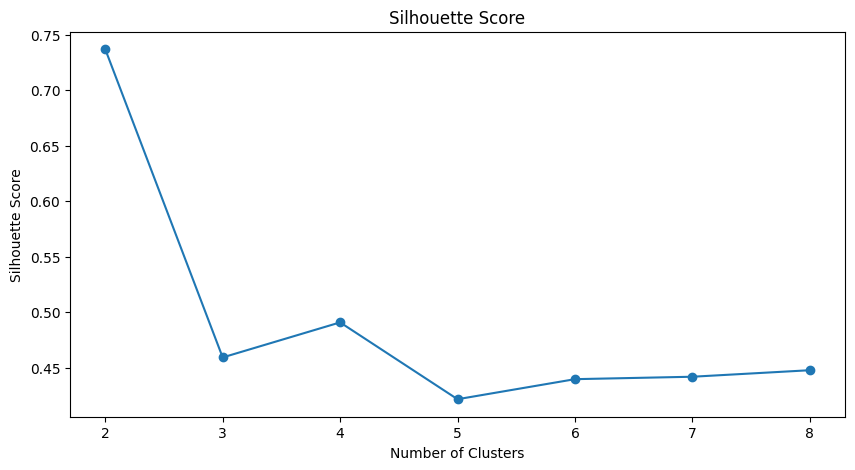

In [26]:
plt.figure(figsize = (10,5))

plt.plot(list(k_range), silhouette_scores, marker = "o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [27]:
#lets start with k = 2, and find its characteristics

kmeans = KMeans(n_clusters = 2, random_state =42, n_init = 10)

customer_clustering["cluster"] = kmeans.fit_predict(scaled_feature)

In [32]:
cluster_profile = customer_clustering.reset_index().groupby("cluster").agg(
    customer_count = ("customer_unique_id", "count"),
    average_recency=("recency", "mean"),
    median_recency=("recency", "median"),
    average_frequency=("frequency", "mean"),
    median_frequency=("frequency", "median"),
    average_monetary=("monetary", "mean"),
    median_monetary=("monetary", "median")).round(2)

In [36]:
cluster_business_profile = customer_clustering.reset_index().groupby(
    "cluster"
).agg(
    customer_count=("customer_unique_id", "count"),
    total_revenue=("monetary", "sum"),
    average_spend=("monetary", "mean"),
    median_spend=("monetary", "median"),
    average_frequency=("frequency", "mean"),
    average_recency=("recency", "mean")
).round(2)

cluster_business_profile

,customer_count,total_revenue,average_spend,median_spend,average_frequency,average_recency
cluster,,,,,,
0,92501,12781854.24,138.18,87.00,1.00,243.15
1,2919,809789.46,277.42,182.88,2.11,225.34


In [37]:
cluster_business_profile["revenue_percentage"] = (
    cluster_business_profile["total_revenue"]
    / cluster_business_profile["total_revenue"].sum()
    * 100
).round(2)

cluster_business_profile

,customer_count,total_revenue,average_spend,median_spend,average_frequency,average_recency,revenue_percentage
cluster,,,,,,,
0,92501,12781854.24,138.18,87.00,1.00,243.15,94.04
1,2919,809789.46,277.42,182.88,2.11,225.34,5.96


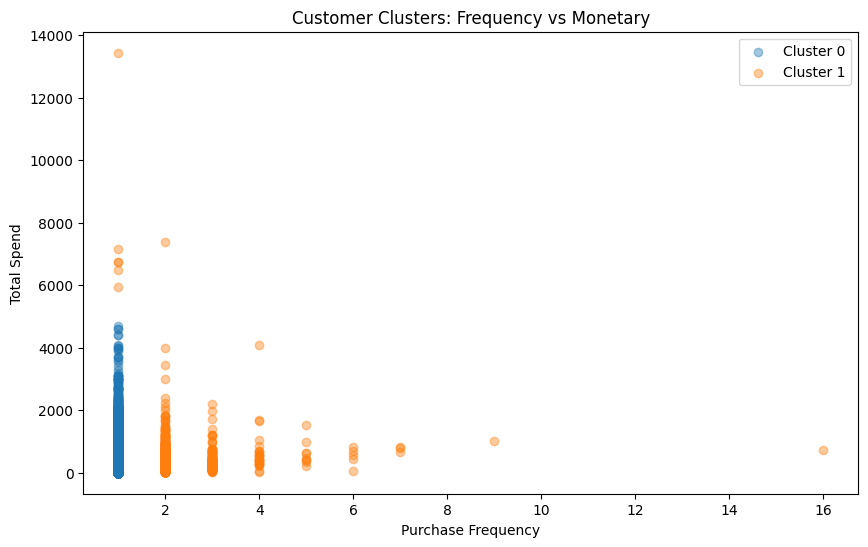

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cluster in sorted(customer_clustering["cluster"].unique()):

    cluster_data = customer_clustering[
        customer_clustering["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["frequency"],
        cluster_data["monetary"],
        alpha=0.4,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spend")
plt.title("Customer Clusters: Frequency vs Monetary")
plt.legend()

plt.show()

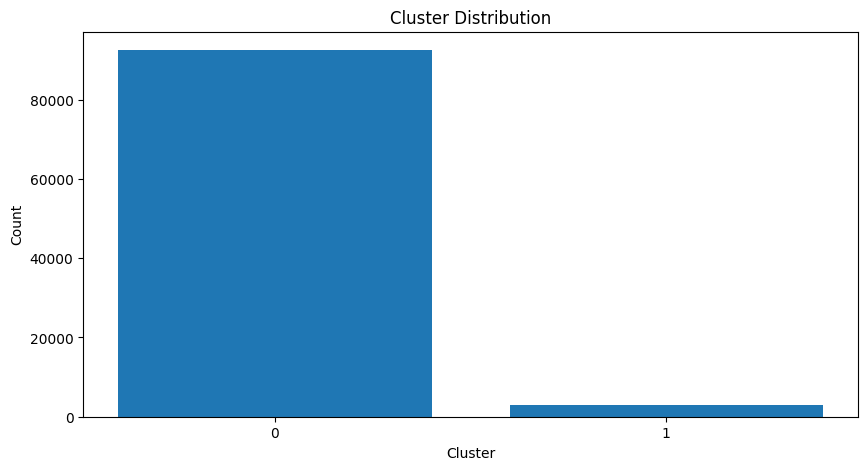

In [45]:
cluster_counts = customer_clustering["cluster"].value_counts().reset_index()

plt.figure(figsize = (10, 5))

# Corrected line: Use 'cluster' column for x-axis and 'count' column for y-axis
plt.bar(cluster_counts['cluster'].astype(str), cluster_counts['count'])

plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Cluster Distribution")

plt.xticks(cluster_counts.index, cluster_counts["cluster"])

plt.show()

In [46]:
#PCA
from sklearn.decomposition import PCA

In [47]:
pca = PCA(n_components = 2)

pca_feature = pca.fit_transform(scaled_feature)

In [49]:
customer_clustering["PC1"] = pca_feature[:, 0]
customer_clustering["PC2"] = pca_feature[:, 1]

In [51]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.36938074 0.3334481 ]
Total explained variance: 0.702828841954745


In [53]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=[
        "recency",
        "frequency",
        "monetary"
    ],
    index=[
        "PC1",
        "PC2"
    ]
)

pca_components

,recency,frequency,monetary
PC1,0.707650,0.692391,-0.140806
PC2,-0.007201,0.206340,0.978454


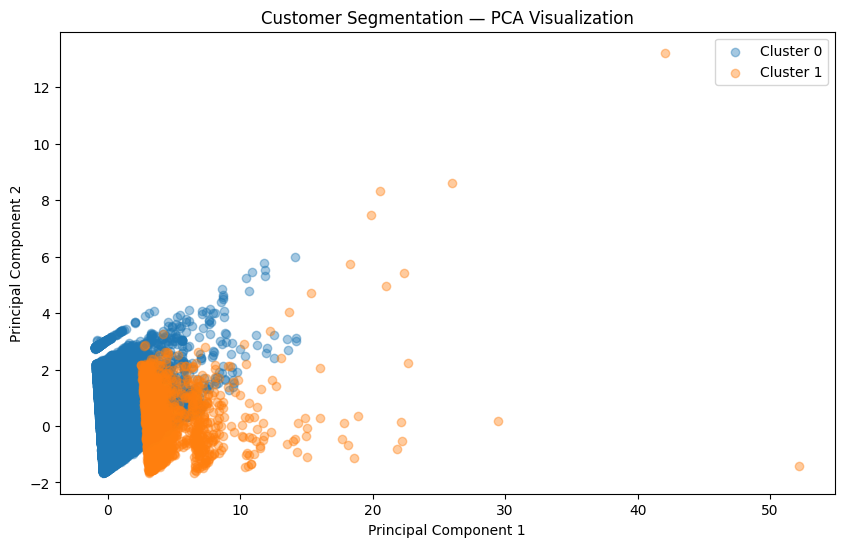

In [54]:
plt.figure(figsize=(10, 6))

for cluster in sorted(
    customer_clustering["cluster"].unique()
):

    cluster_data = customer_clustering[
        customer_clustering["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        alpha=0.4,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation — PCA Visualization")
plt.legend()

plt.show()